In [1]:
# Calculation of minimum of best features and maximum of worst features
import numpy as np
import os
import pandas as pd
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
plt.style.use("my_style.mplstyle")

Duplicate key in file 'my_style.mplstyle', line 25 ('text.usetex: False')
Duplicate key in file 'my_style.mplstyle', line 26 ('font.family: sans-serif')
Duplicate key in file 'my_style.mplstyle', line 27 ('font.sans-serif: Helvetica')


In [2]:
models=['GNO', 'UNO', 'PINK', 'BROWN', 'VIOLET', # noises (R)
        'AR1_GNO', 'STAR_GNO', #    ARMA (R)
        'ARNOLD', 'CHIRIKOV', 
        'OU', 'Oscillator',# Conservative chaotic maps (R)
        'BRW_cont', 
        'HENR_diverse', 'HENR_same', 'QUADRATIC_RSUM', # Sum of frwd and bckwd realisations of chaotic maps (R)
        'AR1_UNO', 'ARMA11_UNO', 'AR3_Gamma', 'N_AR2', 'SETAR1_GNO', 'SETAR2_GNO',
        'HEN', 'HEN_SUM', 'LOGISTIC4', 'LOGISTIC38284', 'QUADRATIC', # Chaotic maps (I)
        'MODA', 'LLOG', # Other deterministic (I)
        'SINE_STOCH', # Other stochastic (I)
        'LORENZ_SUM', 'ROSSLER_SUM', 
        'MACKEYGLASS17', 'VDP', 
        'LORENZ_STOCH_SUM',
        'VDP_STOCH'
        ]

print('Models:', models)

model_keywords={ # discrete
                'GNO': 'reversible', 'UNO': 'reversible', 'PINK': 'reversible', 'BROWN': 'reversible', 'VIOLET': 'reversible',
                'AR1_GNO': 'reversible', 'STAR_GNO': 'reversible',
                'ARNOLD': 'reversible', 'CHIRIKOV': 'reversible',
                'HENR_diverse': 'reversible', 'HENR_same': 'reversible', 'QUADRATIC_RSUM': 'reversible',
                'AR1_UNO': 'irreversible', 'ARMA11_UNO': 'irreversible', 'AR3_Gamma': 'irreversible', 'N_AR2': 'irreversible', 'SETAR1_GNO': 'irreversible', 'SETAR2_GNO': 'irreversible', 
                'HEN': 'irreversible', 'HEN_SUM': 'irreversible', 'LOGISTIC4': 'irreversible', 'LOGISTIC38284': 'irreversible','QUADRATIC': 'irreversible',
                'MODA': 'irreversible', 'LLOG': 'irreversible',
                'SINE_STOCH': 'irreversible',
                # continuous
                'BRW_cont': 'reversible', 'OU': 'reversible', 'Oscillator': 'reversible',
                'LORENZ_SUM': 'irreversible', 'ROSSLER_SUM': 'irreversible',
                'MACKEYGLASS17': 'irreversible', 'VDP': 'irreversible',
                'LORENZ_STOCH_SUM': 'irreversible',
                'VDP_STOCH': 'irreversible'
        }

# Idea: put together discrete and continuou models with same caratteristics 
# category models = { iid noise, arma, chaos, sum chaos, other deterministic, other stochastic}
cathegory_models = {
    'GNO': 'iid noise', 'UNO': 'iid noise', 'PINK': 'iid noise', 'BROWN': 'iid noise', 'VIOLET': 'iid noise',   
        'AR1_GNO': 'ARMA', 'STAR_GNO': 'ARMA', 'AR1_UNO': 'ARMA', 'ARMA11_UNO': 'ARMA', 'AR3_Gamma': 'ARMA', 'N_AR2': 'ARMA', 'SETAR1_GNO': 'ARMA', 'SETAR2_GNO': 'ARMA',
        'ARNOLD': 'chaos', 'CHIRIKOV': 'chaos', 'HEN': 'chaos',  'LOGISTIC4': 'chaos', 'LOGISTIC38284': 'chaos', 'QUADRATIC': 'chaos',  
        'HENR_diverse': 'sum chaos', 'HENR_same': 'sum chaos',  'QUADRATIC_RSUM': 'sum chaos', 'HEN_SUM': 'sum chaos', 'LORENZ_SUM': 'sum chaos', 'ROSSLER_SUM': 'sum chaos',
        'MODA': 'other deterministic', 'LLOG': 'other deterministic', 'MACKEYGLASS17': 'other deterministic', 'VDP': 'other deterministic', 'Oscillator': 'other deterministic',
        'SINE_STOCH': 'other stochastic', 'OU': 'other stochastic', 'BRW_cont': 'other stochastic','LORENZ_STOCH_SUM': 'other stochastic','VDP_STOCH': 'other stochastic'
}

Models: ['GNO', 'UNO', 'PINK', 'BROWN', 'VIOLET', 'AR1_GNO', 'STAR_GNO', 'ARNOLD', 'CHIRIKOV', 'OU', 'Oscillator', 'BRW_cont', 'HENR_diverse', 'HENR_same', 'QUADRATIC_RSUM', 'AR1_UNO', 'ARMA11_UNO', 'AR3_Gamma', 'N_AR2', 'SETAR1_GNO', 'SETAR2_GNO', 'HEN', 'HEN_SUM', 'LOGISTIC4', 'LOGISTIC38284', 'QUADRATIC', 'MODA', 'LLOG', 'SINE_STOCH', 'LORENZ_SUM', 'ROSSLER_SUM', 'MACKEYGLASS17', 'VDP', 'LORENZ_STOCH_SUM', 'VDP_STOCH']


In [3]:
cwd = os.getcwd()

dir_hctsa= cwd+'/data-analysis/'
dir_accuracy= cwd+'/data-analysis/accuracy/'
dir_zero=cwd+'/data-zero/'
dir_figures=cwd+'/data-analysis/figures/'

In [4]:
# Load good performing features
df_ops_good = pd.read_csv(dir_accuracy+'df_accuracy_good_1NN.csv')
df_ops_all = pd.read_csv(dir_accuracy+'df_accuracy_abs_1NN_sorted.csv')


# Load ops zero
df_ops_zero = pd.read_csv(dir_zero+'df_ops_zero.csv')

# Check what good features are among the zero ones
common_values = pd.merge(df_ops_good, df_ops_zero, left_on='Operation', right_on='Name', how='inner')
# Display the common values
print(common_values)

Empty DataFrame
Columns: [Operation, Accuracy, Name, Value]
Index: []


In [5]:
# Load true-false and predicted values
df_truefalse = pd.read_csv(dir_accuracy+'df_true_false_abs_1NN.csv')
df_truefalse.set_index(['Model'], inplace=True)

df_pred = pd.read_csv(dir_accuracy+'df_pred_abs_1NN.csv')
df_pred.set_index(['Model'], inplace=True)

df_good_truefalse = df_truefalse[df_ops_good['Operation']] # subset of df_truefalse with only good operations
df_good_pred = df_pred[df_ops_good['Operation']] # subset of df_pred with only good operations
# Already discarded 'CO_TranslateShape' in df_ops_good


In [6]:
# Compute minimum and maximum of accuracy of the features per process
# good operations
dict_good_accuracy_mdl={}
dict_min_max={}
dict_min_max_op={}
for model in models:
    dict_good_accuracy_ops={}
    for op in df_ops_good['Operation']: 
        df_mdl=df_good_truefalse.loc[model,op] # extract True/False labels for model and operation
        # Compute the accuacy by averaging (true = 1 and false = 0) so the average gives me the propotion of True
        avg=df_mdl.mean()
        dict_good_accuracy_ops[op]=avg
    dict_good_accuracy_mdl[model]=dict_good_accuracy_ops
    dict_min_max[model] = {'min': min(dict_good_accuracy_ops.values())*100, 'max': max(dict_good_accuracy_ops.values())*100}  

# Accuracy for good operations per process (averaged over the repeated time series)
df_good_accuracy_mdl=pd.DataFrame(dict_good_accuracy_mdl).T * 100 # Convert to percentage

# Convert to DataFrame
df_min_max = pd.DataFrame(dict_min_max).T

# Only for irreversible models
df_min_max_irreversible = df_min_max[df_min_max.index.isin([model for model in models if model_keywords[model] == 'irreversible'])]

# Find minimum and maximum values
min_max_value = df_min_max_irreversible['max'].min()
max_min_value = df_min_max_irreversible['min'].max()
print(f'Minimum of maximum values: {min_max_value}')
print(f'Maximum of minimum values: {max_min_value}')

Minimum of maximum values: 99.0
Maximum of minimum values: 28.999999999999996


In [8]:
# Accuracy of irreversible models
df_accuracy_irr = df_good_accuracy_mdl[df_good_accuracy_mdl.index.isin([model for model in models if model_keywords[model] == 'irreversible'])]

# Extract column for which all numbers are greater than 0.29
df_best = df_accuracy_irr.loc[:, (df_accuracy_irr > 0.29).all(axis=0)]
# Names of the best operations
best_ops = df_best.columns.tolist() # Operations with accuracy > 0.29 for all irreversible models


In [9]:
# add category column to df_good_accuracy_mdl
df_good_accuracy_mdl['category'] = df_good_accuracy_mdl.index.map(cathegory_models)

# Fix procedd. With 2 features: AC_nl_001 and SB_MotifTwo_diff_uu
## All processes

['iid noise', 'ARMA', 'chaos', 'sum chaos', 'other deterministic', 'other stochastic']


/opt/miniconda3/envs/ts_env/lib/python3.12/site-packages/matplotlib/cbook.py:1314: RuntimeWarning: invalid value encountered in scalar multiply
  loval = q1 - whis * stats['iqr']
/opt/miniconda3/envs/ts_env/lib/python3.12/site-packages/matplotlib/cbook.py:1315: RuntimeWarning: invalid value encountered in scalar multiply
  hival = q3 + whis * stats['iqr']


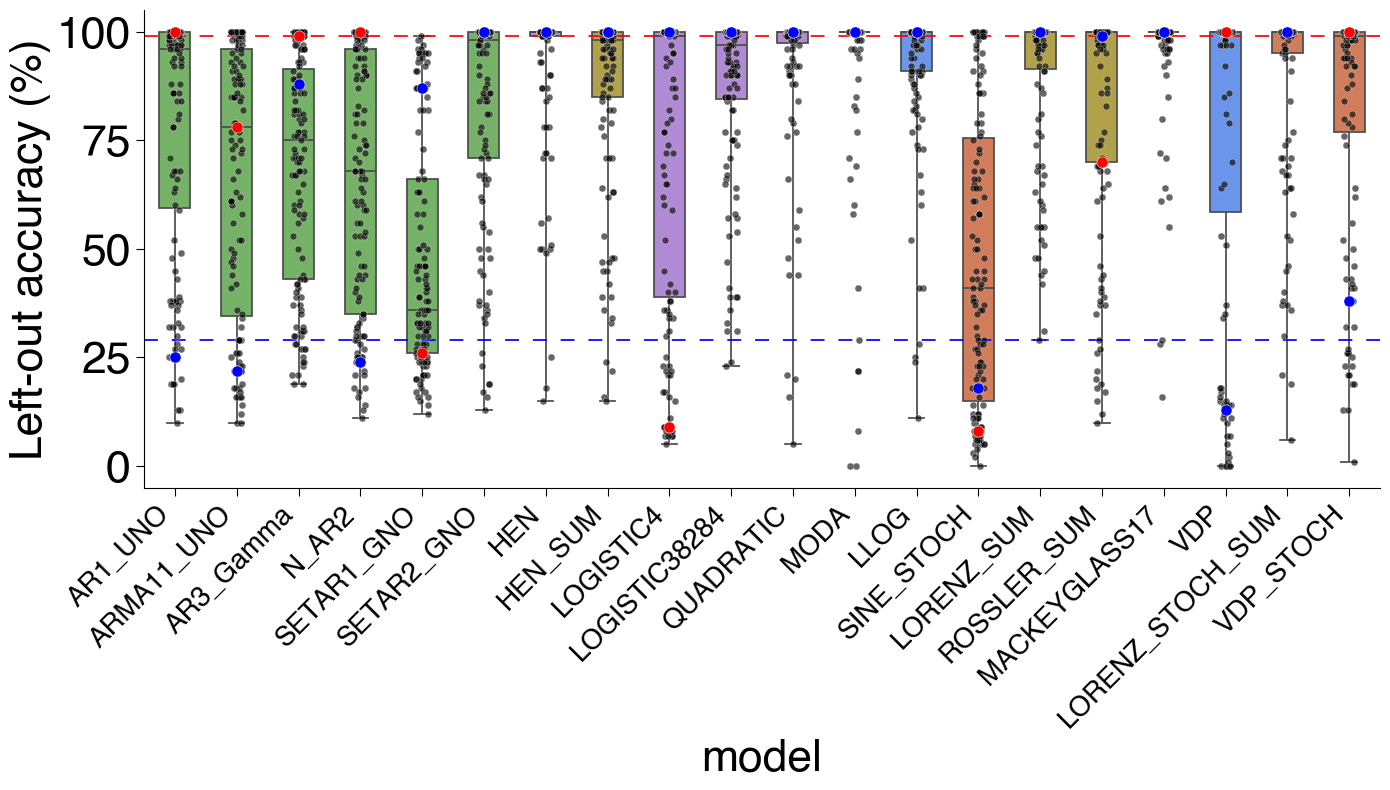

In [16]:
plt.figure(figsize=(14, 8))
# add category column to df_good_accuracy_mdl
df_good_accuracy_mdl['category'] = df_good_accuracy_mdl.index.map(cathegory_models)

palette_c = ["#e96196",
            "#6dbe59",
            "#b07de2",
            "#c2ad39",
            "#568eff",
            "#e57548",]
category = ['iid noise', 'ARMA', 'chaos', 'sum chaos', 'other deterministic', 'other stochastic']
print(category)
category_palette = dict(zip(category, palette_c))


#discard category column
df_good_accuracy_mdl = df_good_accuracy_mdl.drop(columns=['category'])

# Select only irreversible models and transpose so each column is a model, rows are operations
df_irr = df_good_accuracy_mdl.loc[
    df_good_accuracy_mdl.index.isin([model for model in models if model_keywords[model] == 'irreversible'])
].T

df_melt = df_irr.reset_index().melt(id_vars='index', var_name='model', value_name='accuracy')
df_melt = df_melt.rename(columns={'index': 'operation'})

# Operations
df_melt['is_a'] = df_melt['operation'] == 'AC_nl_001'  
df_melt['is_b'] = df_melt['operation'] ==  'SB_MotifTwo_diff_uu' 

df_melt['category'] = df_melt['model'].map(cathegory_models)

# Boxplot of all data
sns.boxplot(
    x='model',
    y='accuracy',
    hue=df_melt['category'],
    data=df_melt,
    whis=np.inf,
    fliersize=0,
    linewidth=1.25,
    palette=category_palette,
    width=0.5
)

plt.axhline(y=min_max_value, color='red', linestyle=(0, (8, 8)), label='Minimum of Maximum Values', linewidth=1.25)
plt.axhline(y=max_min_value, color='blue', linestyle=(0, (8, 8)), label='Maximum of Minimum Values', linewidth=1.25)

# Overlay all points except operation 'a' in black
sns.stripplot(
    x='model',
    y='accuracy',
    data=df_melt[~df_melt['is_a'] & ~df_melt['is_b']],
    color='black',
    dodge=False,
    alpha=0.6,
    linewidth=0.35,
    edgecolor='white',
    jitter=True,
    size=5
)

# Overlay operation 'a' in red
sns.stripplot(
    x='model',
    y='accuracy',
    data=df_melt[df_melt['is_a']],
    color='red',
    dodge=False,
    alpha=1,
    linewidth=0.35,
    edgecolor='white',
    jitter=True,
    size=8,  
    marker='o'
)

# Overlay operation 'b' in blue
sns.stripplot(
    x='model',
    y='accuracy',
    data=df_melt[df_melt['is_b']],
    color='blue',
    dodge=False,
    alpha=1,
    linewidth=0.35,
    edgecolor='white',
    jitter=True,
    size=8, 
    marker='o'
)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=20)

plt.tight_layout()


plt.ylabel('Left-out accuracy (%)')

# hide the legend
plt.legend([],[], frameon=False)





## One representative process per family

['iid noise', 'ARMA', 'chaos', 'sum chaos', 'other deterministic', 'other stochastic']


/var/folders/wz/jq7_490s6t1dh9vzst6cqgdc0000gp/T/ipykernel_76637/1505306591.py:112: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  plt.legend(


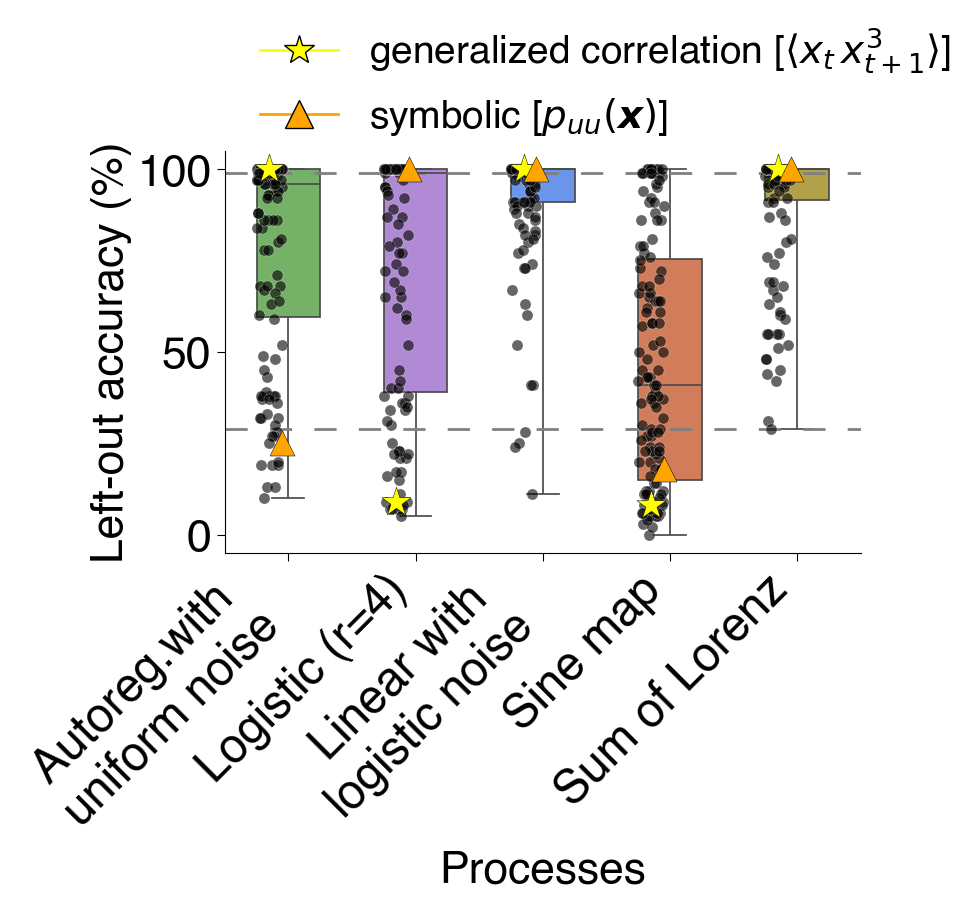

In [ ]:
import matplotlib.lines as mlines

# Do the same plot but only for [LLOG, SINE_STOCH]
df_melt_filtered = df_melt[df_melt['model'].isin(['AR1_UNO', 'LOGISTIC4', 'LORENZ_SUM', 'LLOG', 'SINE_STOCH'])]
palette_c_dark = [
    "#4e9d3f",  
    "#8c55c4",  
    "#9e8b22",  
    "#2f6ce0",  
    "#c25628", 
]
category = ['iid noise', 'ARMA', 'chaos', 'sum chaos', 'other deterministic', 'other stochastic']
print(category)
category_palette_dark = dict(zip(category, palette_c_dark))

# move lorenz sum close to logistic4
plt.figure(figsize=(8, 8))
ax = sns.boxplot(
    x='model',
    y='accuracy',
    hue=df_melt_filtered['category'],
    data=df_melt_filtered,
    whis=np.inf,
    fliersize=0,
    linewidth=1.25,
    palette=category_palette,
    width=0.5
)

# Overlay all points except operation 'a' in black
sns.stripplot(
    x='model',
    y='accuracy',
    data=df_melt_filtered[~df_melt_filtered['is_a'] & ~df_melt_filtered['is_b']],
    color='black',
    dodge=False,
    alpha=0.6,
    linewidth=0.3,
    edgecolor='white',
    jitter=True,
    size=8
)      


plt.axhline(y=min_max_value, color='gray', linestyle=(0,(8,8)), linewidth=2)
plt.axhline(y=max_min_value, color='gray', linestyle=(0,(8,8)), linewidth=2)

# Overlay operation 'a' in yellow *
sns.stripplot(
    x='model',
    y='accuracy',
    data=df_melt_filtered[df_melt_filtered['is_a']],
    color='yellow',
    dodge=False,
    alpha=1,
    linewidth=0.35,
    edgecolor='black',
    jitter=True,
    size=22,  # slightly larger if desired
    marker='*',
    label ='generalized correlation'  # Add label for legend
)   
# offset the star a bit left in all boxes
for collection in ax.collections:
    offsets = collection.get_offsets()
    offsets[:, 0] -= 0.1  # Adjust the value to move left or right
    collection.set_offsets(offsets)


# Overlay operation 'b' in orange ^
sns.stripplot(
    x='model',
    y='accuracy',
    data=df_melt_filtered[df_melt_filtered['is_b']],
    color='orange',
    dodge=False,
    alpha=1,
    linewidth=0.35,
    edgecolor='black',
    jitter=True,
    size=18,  # slightly larger if desired
    marker='^', label ='symbolic'  # Add label for legend
)
# offset the triangle a bit left in all boxes
for collection in ax.collections:
    offsets = collection.get_offsets()
    offsets[:, 0] -= 0.05  # Adjust the value to move left or right
    collection.set_offsets(offsets)


plt.xticks(rotation=45, ha='right', fontsize=28)

plt.tight_layout()


handle_red = mlines.Line2D([], [], color='yellow', marker='*', linestyle='-', markeredgecolor = 'black',
                           markersize=22, label=r"generalized correlation [$\langle x_t \, x_{t+1}^3\rangle$]")

handle_blue = mlines.Line2D([], [], color='orange', marker='^', linestyle='-', markeredgecolor = 'black',
                           markersize=20, label=r"symbolic [$p_{uu}(\boldsymbol{x})$]")

handle_black = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                             markersize=14, label='_')
plt.legend(
    handles=[handle_red, handle_blue, handle_black],
    loc='upper left',
    bbox_to_anchor=(0, 1.4),
    fontsize=28
)

# rewrite x-ticks labels
plt.xticks([0, 1, 2, 3, 4], ['Autoreg.with \n uniform noise', 'Logistic (r=4)', 'Linear with \n logistic noise', 'Sine map', 'Sum of Lorenz'], fontsize=34)

plt.xlabel('Processes')
plt.ylabel('Left-out accuracy (%)')



# save svg
plt.savefig(dir_figures+'min_max_plot_nolgd.svg', format='svg', bbox_inches='tight', dpi=300)

# Fix features

In [44]:
# Compute minimum and maximum of accuracy across features (consider only irreversible models)
df_good_accuracy_irr = df_good_accuracy_mdl[df_good_accuracy_mdl.index.isin([model for model in models if model_keywords[model] == 'irreversible'])]
dict_min_max_op = {}
for op in df_ops_good['Operation']:
    df_op = df_good_accuracy_irr[op]
    dict_min_max_op[op] = {'min': df_op.min(axis=0), 'max': df_op.max(axis=0)}

# Convert to DataFrame
df_min_max_op = pd.DataFrame(dict_min_max_op).T 

# Min and max values across all operations
min_max_value_op = df_min_max_op['max'].min()
max_min_value_op = df_min_max_op['min'].max()

print(f'Minimum of maximum values across operations: {min_max_value_op}')
print(f'Maximum of minimum values across operations: {max_min_value_op}')


Minimum of maximum values across operations: 99.0
Maximum of minimum values across operations: 48.0


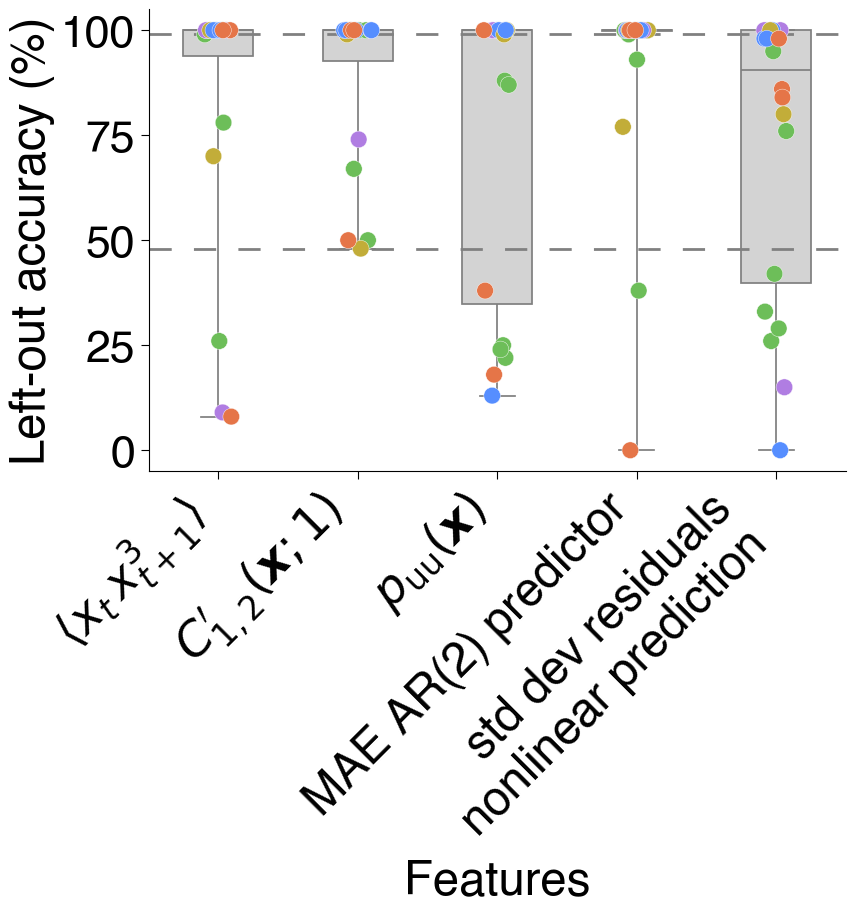

In [61]:
# Filter operations
operations = ['AC_nl_001', 'CO_glscf_1_2_1', 'SB_MotifTwo_diff_uu', 'PH_Walker_biasprop_01_05_w_mean', 'NL_MS_nlpe_3_ac_stde']
#SB_MotifTwo_diff_uu
#PH_Walker_biasprop_01_05_w_mean
#AC_nl_001
#MF_steps_ahead_ar_2_6_mabserr_1
#NL_MS_fnn_1_10_mi_5_1_max1stepchange

df_melt2 = df_good_accuracy_irr.reset_index().melt(id_vars='index', var_name='operation', value_name='accuracy')
df_melt2 = df_melt2.rename(columns={'index': 'model'})

df_filtered = df_melt2[df_melt2['operation'].isin(operations)]

df_filtered = df_filtered.copy()  

# Add category column for models
df_filtered['category'] = df_filtered['model'].map(cathegory_models)


df_filtered['is_a'] = df_filtered['model'] == 'AR1_UNO'
df_filtered['is_b'] = df_filtered['model'] ==  'LOGISTIC4'

palette_c = ["#e96196",
            "#6dbe59",
            "#b07de2",
            "#c2ad39",
            "#568eff",
            "#e57548",]
category = ['iid noise', 'ARMA', 'chaos', 'sum chaos', 'other deterministic', 'other stochastic']

category_palette = dict(zip(category, palette_c))

# Plot operations ordered as in operations
df_filtered['operation'] = pd.Categorical(df_filtered['operation'], categories=operations, ordered=True)

plt.figure(figsize=(9, 6))
sns.boxplot(
    x='operation',
    y='accuracy',
    data=df_filtered,
    whis=np.inf,
    fliersize=0,
    linewidth=1.25,
    color='lightgray',  # Use the first color for correlation
    width=0.5
)
# Overlay filtered operations 
sns.stripplot(
    x='operation',
    y='accuracy',
    data=df_filtered,
    hue='category',
    palette=category_palette,
    dodge=False,
    alpha=1,
    linewidth=0.3,
    edgecolor='white',
    jitter=True,
    size=12,  #slightly larger if desired
    marker='o'
)


plt.xticks(rotation=45, ha='right', fontsize=20)

plt.xticks([0, 1, 2, 3, 4], [r'$\langle x_t \, x_{t+1}^3\rangle$', r'$C^\prime_{1,2}(\boldsymbol{x};1) $', r'$p_{\text{uu}}(\boldsymbol{x})$', 'MAE AR(2) predictor', 'std dev residuals\n nonlinear prediction'], fontsize=34)



# Horizontal reference lines
plt.axhline(y=min_max_value_op, color='gray', linestyle=(0, (8,8)), linewidth=2)
plt.axhline(y=max_min_value_op, color='gray', linestyle=(0, (8,8)), linewidth=2)



# xlabel
plt.xlabel('Features', fontsize=34)
plt.ylabel('Left-out accuracy (%)', fontsize=34)


handle_red = mlines.Line2D([], [], color='yellow', marker='*', linestyle='-', markeredgecolor = 'black',
                           markersize=20, label=r"AR1_UNO")

handle_blue = mlines.Line2D([], [], color='orange', marker='^', linestyle='-', markeredgecolor = 'black',
                           markersize=18, label=r"LOGISTIC_4")

handle_black = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                             markersize=18, label='other processes')


plt.legend([],[], frameon=False)

# save svg
plt.savefig(dir_figures+'min_max_plot_operations.svg', format='svg', bbox_inches='tight', dpi=300)


